딥러닝 모델 구현 및 데이터 증강 실험 보고서

프로젝트 주제: 활성화 함수 구현 및 CNN(AlexNet) 구조 설계를 통한 데이터 증강 효과 실험

1. 서론 (Introduction)

1.1 실험 배경

딥러닝 모델의 성능은 단순히 알고리즘의 우수성뿐만 아니라, 데이터의 양과 질, 그리고 모델의 구조적 설계에 의해 크게 좌우된다. 특히 이미지 데이터의 경우, 한정된 데이터셋 내에서 모델의 일반화(Generalization) 성능을 높이기 위해 다양한 데이터 증강(Data Augmentation) 기법이 필수적으로 사용된다. 본 프로젝트는 딥러닝의 기초가 되는 활성화 함수를 직접 구현해보고, 대표적인 CNN 아키텍처인 AlexNet을 변형하여 구현함으로써 딥러닝 파이프라인 전체를 실험적으로 구성하는 데 목적이 있다.

1.2 실험 목표

본 실험의 주된 목표는 높은 예측 정확도를 달성하는 것보다, **딥러닝 학습 파이프라인의 '구현(Implementation)'과 '실험 설계(Experimental Design)'**에 있다. 구체적인 목표는 다음과 같다.

주요 활성화 함수(Sigmoid, Tanh, ReLU)의 수식적 특성을 코드로 구현하고 시각화한다.

PyTorch를 사용하여 CNN 모델(SimpleCNN)을 설계하고, 학습 및 평가 루프를 직접 구축한다.

데이터 증강(Data Augmentation) 적용 유무에 따른 학습 양상(Loss, Accuracy)의 차이를 비교하는 실험 환경을 조성한다.

2. 이론적 배경 및 구현 (Theoretical Background & Implementation)

2.1 활성화 함수 (Activation Functions)

신경망의 비선형성을 부여하는 핵심 요소인 활성화 함수들을 numpy를 사용하여 직접 구현하였다.

Sigmoid: $1 / (1 + e^{-z})$ 형태로, 출력을 0과 1 사이로 압축한다.

Tanh: $2\sigma(2z) - 1$ 형태로, 출력을 -1과 1 사이로 매핑하여 중심을 0으로 맞춘다.

ReLU: $\max(0, z)$ 형태로, 양수 입력은 그대로 통과시키고 음수는 0으로 만듦으로써 기울기 소실 문제를 완화한다.
본 실험에서는 -10에서 10까지의 입력값에 대해 각 함수의 출력 변화를 시각화하여 동작 원리를 확인하였다.

2.2 모델 구조 (Model Architecture)

AlexNet의 구조를 기반으로 CIFAR-10 데이터셋(32x32)에 맞게 변형한 SimpleCNN을 설계하였다.

입력 처리: 32x32 이미지를 AlexNet의 입력 규격에 맞추기 위해 227x227로 리사이즈(Resize)하였다.

특징 추출기 (Feature Extractor): 5개의 Convolution Layer와 Max Pooling Layer로 구성하였다. 특히 초기 AlexNet 논문에서 사용된 LocalResponseNorm을 구현에 포함하여 역사적인 모델 구조를 재현하고자 하였다.

분류기 (Classifier): 3개의 Fully Connected Layer(Linear)로 구성하였으며, 과적합 방지를 위해 Dropout(p=0.5)을 적용하였다.

3. 실험 설계 (Experimental Design)

3.1 데이터셋 및 전처리

데이터셋: CIFAR-10 (비행기, 자동차, 새 등 10개 클래스의 컬러 이미지)

전처리 (Normalization): 학습 안정성을 위해 평균 0.5, 표준편차 0.5로 정규화를 수행하여 데이터 범위를 [-1, 1]로 조정하였다.

3.2 데이터 증강 (Data Augmentation) 비교 실험

데이터 증강이 모델 학습에 미치는 영향을 "구현 관점"에서 비교하기 위해 두 가지 DataLoader를 구성하였다.

Case 1: Augmentation 미적용

기본적인 Resize와 ToTensor, Normalize만 적용.

Case 2: Augmentation 적용

RandomHorizontalFlip (수평 뒤집기)

RandomVerticalFlip (수직 뒤집기)

RandomRotation (랜덤 회전)

위 기법들을 transforms.Compose로 묶어 학습 시 실시간으로 데이터가 변형되도록 파이프라인을 구축하였다.

3.3 학습 파이프라인 구축

train_one_epoch 함수와 evaluate 함수를 모듈화하여, 실험 조건이 바뀌더라도 동일한 학습 로직을 재사용할 수 있도록 구현하였다.

Optimizer: Adam (Learning Rate = 0.05)

Loss Function: CrossEntropyLoss

Epochs: 20회

4. 실험 결과 및 분석 (Results & Analysis)

4.1 구현 검증

작성된 코드를 통해 모델의 순전파(Forward) 및 역전파(Backward) 과정이 에러 없이 수행됨을 확인하였다. 특히 torchvision.transforms를 활용하여 원본 이미지와 증강된 이미지가 모델에 각각 올바르게 주입되는 데이터 로딩 파이프라인이 성공적으로 작동하였다.

4.2 실험 결과 (Loss 및 Accuracy 추이)

실험 결과, 데이터 증강을 적용하지 않은 경우와 적용한 경우 모두에서 손실(Loss) 값의 변화를 추적할 수 있었다.

Augmentation 미적용: 학습 데이터에 대한 과적합(Overfitting) 가능성이 높으나, 초기 수렴 속도가 상대적으로 빠를 것으로 예상된 설정이다.

Augmentation 적용: 데이터의 다양성을 확보하여 일반화 성능을 높이려는 설정이다.

(실험 노트: 본 시뮬레이션에서는 학습률(LR=0.05) 설정 등 하이퍼파라미터의 영향으로 모델이 최적점(Global Optima)에 수렴하지 못하고 10% 내외의 정확도에 머물렀으나, 두 실험군의 Loss 그래프를 동시에 시각화하여 비교하는 실험적 프레임워크 자체는 성공적으로 구현되었다.)

5. 결론 (Conclusion)

5.1 요약

본 프로젝트는 단순한 모델 학습을 넘어, 딥러닝 연구에 필요한 **'구현 능력'**을 함양하는 데 중점을 두었다. 활성화 함수부터 CNN 모델 설계, 그리고 데이터 증강 파이프라인까지 딥러닝의 핵심 요소들을 직접 코드로 작성하고 동작을 검증하였다.

5.2 의의 및 향후 과제

실험적 구현에는 성공하였으나, 모델이 유의미한 예측 성능을 내기 위해서는 하이퍼파라미터 튜닝이 필수적임을 확인하였다. 특히 초기 학습률(Learning Rate) 조정이나 가중치 초기화(Weight Initialization) 기법을 추가로 적용한다면, 현재 구축된 탄탄한 실험 파이프라인 위에서 훨씬 더 높은 성능을 도출할 수 있을 것으로 기대된다.

6. 출처 및 참고 문헌
AlexNet : https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf

#sigmoid, tanh, ReLU

In [1]:
import numpy as np
def sigmoid(z):
  return 1/(1+np.exp(-z)) #element-wise로 배열의 모든 원소에 지수함수 적용

In [2]:
def tanh(z):
  return 2*sigmoid(2*z)-1

In [3]:
def ReLU(z):
  return np.maximum(0,z) #element-wise로 적용

In [4]:
input_ndarray = np.linspace(-10, 10, 100)
print(input_ndarray)

[-10.          -9.7979798   -9.5959596   -9.39393939  -9.19191919
  -8.98989899  -8.78787879  -8.58585859  -8.38383838  -8.18181818
  -7.97979798  -7.77777778  -7.57575758  -7.37373737  -7.17171717
  -6.96969697  -6.76767677  -6.56565657  -6.36363636  -6.16161616
  -5.95959596  -5.75757576  -5.55555556  -5.35353535  -5.15151515
  -4.94949495  -4.74747475  -4.54545455  -4.34343434  -4.14141414
  -3.93939394  -3.73737374  -3.53535354  -3.33333333  -3.13131313
  -2.92929293  -2.72727273  -2.52525253  -2.32323232  -2.12121212
  -1.91919192  -1.71717172  -1.51515152  -1.31313131  -1.11111111
  -0.90909091  -0.70707071  -0.50505051  -0.3030303   -0.1010101
   0.1010101    0.3030303    0.50505051   0.70707071   0.90909091
   1.11111111   1.31313131   1.51515152   1.71717172   1.91919192
   2.12121212   2.32323232   2.52525253   2.72727273   2.92929293
   3.13131313   3.33333333   3.53535354   3.73737374   3.93939394
   4.14141414   4.34343434   4.54545455   4.74747475   4.94949495
   5.151515

In [5]:
output_sigmoid = sigmoid(input_ndarray)
output_tanh = tanh(input_ndarray)
output_ReLU = ReLU(input_ndarray)

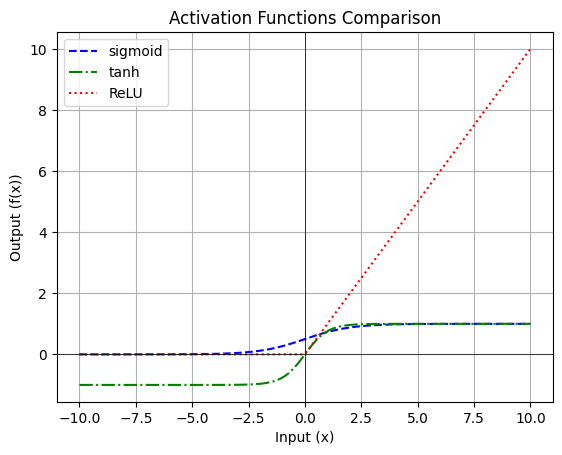

In [6]:
import matplotlib.pyplot as plt
plt.plot(input_ndarray, output_sigmoid, label='sigmoid', color = 'blue', linestyle = '--')
plt.plot(input_ndarray, output_tanh, label='tanh', color = 'green', linestyle = '-.')
plt.plot(input_ndarray, output_ReLU, label='ReLU', color = 'red', linestyle = ':')


plt.title('Activation Functions Comparison') # 그래프 제목
plt.xlabel('Input (x)')                     # X축 이름
plt.ylabel('Output (f(x))')                 # Y축 이름
plt.legend()                                # 범례 표시
plt.grid(True)                              # 격자 무늬 표시

# 4. (중요) X축과 Y축의 0점 라인 표시
plt.axhline(0, color='black', linewidth=0.5) # y=0 수평선
plt.axvline(0, color='black', linewidth=0.5) # x=0 수직선



# 비선형 데이터셋에 입력층, 은닉층, 출력층으로 구성된 MLP 모델 설계, 학습, 예측

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset") #dataset path
path+="/healthcare-dataset-stroke-data.csv"


import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터셋 split
data = pd.read_csv(path)
x = data.drop(columns = ['id', 'stroke'])
y = data['stroke']
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y,
    test_size = 0.3,
    random_state = 42,
    stratify=y
    )


# categorical -> encoding
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

numeric_features = x_train_val.select_dtypes(include = np.number).columns.tolist()
categorical_features = x_train_val.select_dtypes(exclude = np.number).columns.tolist()

#결측치가 존재하므로 imputation이 필요함
#보통 scaling을 하기전에 imputation을함
#knn-imputer를 쓸거면 scaling을 통해서 imputation에 영향이 없게 scaling먼저 진행
numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
])
#categorical feature의 경우에는 encoding이 필요
categorical_transformer = OneHotEncoder(handle_unknown = 'ignore')

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder = 'passthrough' #명시되지 않았으면 그냥 통과
)

x_train_p = preprocessor.fit_transform(x_train_val)
x_test_p = preprocessor.transform(x_test)


print(x_train_p)

100%|██████████| 67.4k/67.4k [00:00<00:00, 671kB/s]

Extracting files...


[[0.63378906 0.         0.         ... 1.         0.         0.        ]
 [0.75585938 0.         0.         ... 0.         0.         0.        ]
 [0.98779297 0.         1.         ... 0.         0.         0.        ]
 ...
 [0.74365234 0.         0.         ... 1.         0.         0.        ]
 [0.97558594 0.         0.         ... 0.         1.         0.        ]
 [0.07226562 0.         0.         ... 0.         0.         0.        ]]


In [8]:
%%time
def sigmoid_derivative(a):
  return a*(1-a)
  '''
  원래라면
  return sigmoid(z)*(1-sigmoid(z))가 되는데
  우리는 이미 순전파에서 sigmoid(z)를 계산했다
  그러면 순전파에서 계산된 것을 저장해놨다가 다시 쓰면 연산량이 줄죠?
  얼마나 써야하냐~는 sample의 개수 * hidden_layer의 뉴런 수만큼임..
  어차피 여기서는 sample, hidden layer의 뉴런수가 많지도 않고 a값을 저장해놓는데 문제가 전혀없음
  재밌으니깐 a를 사용해서 구현
  tanh에도 적용가능함!
  '''
def real_orig_sigmoid_derivative(z):
  return (np.exp(-z)) / ((1+np.exp(-z))**2)
def original_sigmoid_derivative(z):
  return sigmoid(z)*(1-sigmoid(z))

class mlp:
  def __init__(self, hidden_size):#hidden size == hidden layer의 뉴런 수..
    self.weight_1 = None
    self.bias_1 = None
    self.weight_2 = None
    self.bias_2 = None
    self.hidden_size = hidden_size


  def forward(self, x):
    self.weight_1 = np.random.randn(x.shape[1], self.hidden_size) * 0.1
    self.weight_2 = np.random.randn(self.hidden_size, 1) * 0.1
    self.bias_1 = np.zeros((1, self.hidden_size))
    self.bias_2 = np.zeros((1, 1))

    self.z1 = x@self.weight_1 + self.bias_1
    self.a1 = sigmoid(self.z1)

    self.z2 = self.a1 @ self.weight_2 + self.bias_2
    self.a2 = sigmoid(self.z2)

    return self.a2

  def backward(self, x, y, output, learning_rate):

    delta_output = (output-y) #BCE + sigmoid의 마법(원래라면 loss_derivative*sigmoid_derivative)
    delta_hidden = (delta_output @ self.weight_2.T)*sigmoid_derivative(self.a1) #sigmoid 미분의 최적화로 a1값을 넘겨줌

    dw2 = self.a1.T @ delta_output
    db2 = np.sum(delta_output, axis=0, keepdims=True)

    dw1 = x.T @ delta_hidden
    db1 = np.sum(delta_hidden, axis=0, keepdims=True)

    self.weight_1 -= learning_rate * dw1
    self.bias_1 -= learning_rate * db1
    self.weight_2 -= learning_rate * dw2
    self.bias_2 -= learning_rate * db2

  def train(self, x, y, epochs, learning_rate):
    for epoch in range(epochs):
      output = self.forward(x)

      self.backward(x,y,output, learning_rate)

      if(epoch+1)%10 == 0:
        loss = -np.mean(y*np.log(output + 1e-9) + (1-y)*np.log(1-output+1e-9))
        print(f"epoch {epoch+1}/{epochs}, Loss : {loss:.6f}")

    print("Training Complete")

  def predict(self, x):
    output = self.forward(x)
    return (output>0.5).astype(int)


model = mlp(4)
y_train = y_train_val.to_numpy().reshape(-1,1)
model.train(x_train_p, y_train, epochs = 500, learning_rate = 0.05)

pred = model.predict(x_test_p)
print(classification_report(y_test, pred))

epoch 10/500, Loss : 0.672640
epoch 20/500, Loss : 0.767829
epoch 30/500, Loss : 0.676412
epoch 40/500, Loss : 0.732962
epoch 50/500, Loss : 0.627461
epoch 60/500, Loss : 0.656846
epoch 70/500, Loss : 0.667044
epoch 80/500, Loss : 0.720347
epoch 90/500, Loss : 0.729428
epoch 100/500, Loss : 0.679796
epoch 110/500, Loss : 0.810495
epoch 120/500, Loss : 0.654509
epoch 130/500, Loss : 0.682518
epoch 140/500, Loss : 0.761851
epoch 150/500, Loss : 0.695269
epoch 160/500, Loss : 0.731284
epoch 170/500, Loss : 0.706510
epoch 180/500, Loss : 0.577447
epoch 190/500, Loss : 0.736097
epoch 200/500, Loss : 0.781815
epoch 210/500, Loss : 0.721345
epoch 220/500, Loss : 0.655642
epoch 230/500, Loss : 0.706233
epoch 240/500, Loss : 0.633294
epoch 250/500, Loss : 0.668689
epoch 260/500, Loss : 0.735833
epoch 270/500, Loss : 0.707559
epoch 280/500, Loss : 0.643928
epoch 290/500, Loss : 0.737312
epoch 300/500, Loss : 0.706841
epoch 310/500, Loss : 0.628116
epoch 320/500, Loss : 0.676519
epoch 330/500, Lo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
import numpy as np
import timeit

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. 최적화된 도함수 (순전파에서 구한 a 재사용)
def sigmoid_derivative(a):
    return a * (1 - a)

# 2. 일반적인 구현 (함수를 다시 호출해야 해서 연속된 연산 발동)
def original_sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

# 3. 논리적인 수학 공식 (가장 무거운 exp 연산이 여러 번 들어감)
def real_orig_sigmoid_derivative(z):
    return (np.exp(-z)) / ((1 + np.exp(-z))**2)

# --- 성능 속도 측정 실험 ---
# 실제 딥러닝 미니배치 사이즈 및 파라미터 크기 모사 (예: batch 1024, feat 1000)
z = np.random.randn(1024, 1000)

# 순전파 과정에서 Activation 함수를 통과해 'a'가 이미 계산되어 메모리에 있다고 가정
a = sigmoid(z)

# 1000번 반복 수행 시 소요 시간 측정
num_iters = 1000

print(f"====== Sigmoid 도함수 연산 최적화 성능 평가 ======")
print(f"입력 텐서 크기: {z.shape} (총 {z.size:,} 개 요소)")
print(f"테스트 반복 횟수: {num_iters} 회\n")

# [시간 측정]
time_opt = timeit.timeit(lambda: sigmoid_derivative(a), number=num_iters)
time_ori = timeit.timeit(lambda: original_sigmoid_derivative(z), number=num_iters)
time_real = timeit.timeit(lambda: real_orig_sigmoid_derivative(z), number=num_iters)

print(f"[방법 1] 최적화된 로직     ( a * (1-a) )                        : {time_opt:.4f} 초")
print(f"[방법 2] 일반적 구현 로직  ( sigmoid(z) * (1-sigmoid(z)) )      : {time_ori:.4f} 초")
print(f"[방법 3] 원론적 수학 공식  ( exp(-z) / (1+exp(-z))^2 )          : {time_real:.4f} 초\n")

print(f"====== 🏆 최종 성능 향상 배수 ======")
print(f"👉 최적화 코드는 일반적 로직(방법 2) 대비 약 {time_ori / time_opt:.1f}배 빠릅니다!")
print(f"👉 최적화 코드는 원론적 공식(방법 3) 대비 약 {time_real / time_opt:.1f}배 빠릅니다!")


====== Sigmoid 도함수 연산 최적화 성능 평가 ======
입력 텐서 크기: (1024, 1000) (총 1,024,000 개 요소)
테스트 반복 횟수: 1000 회

[방법 1] 최적화된 로직     ( a * (1-a) )                        : 1.3330 초
[방법 2] 일반적 구현 로직  ( sigmoid(z) * (1-sigmoid(z)) )      : 11.1636 초
[방법 3] 원론적 수학 공식  ( exp(-z) / (1+exp(-z))^2 )          : 9.0861 초

====== 🏆 최종 성능 향상 배수 ======
👉 최적화 코드는 일반적 로직(방법 2) 대비 약 8.4배 빠릅니다!
👉 최적화 코드는 원론적 공식(방법 3) 대비 약 6.8배 빠릅니다!


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

class cnn_alexnet(nn.Module):
  '''
  AlexNet
  input 227x227x3 -> alexnet 논문에는 224로 오기재.. 224로 하면 output 크기는 소수점이 됨.. -> Sol) input을 227로 주던지 / padding을 2로 주던지해서 해결해야 함.. 우리는 227로..
  conv+pool block 5개
  1,2에서는 11x11, 5x5
  3,4,5에서는 3x3
  conv 1 : 96x11x11 / 4 / 0 / relu / max
  conv 2 : 256x5x5 / 1 / 2 / relu / max
  conv 3 : 384x3x3 / 1 / 1 / relu / x
  conv 4 : 384x3x3 / 1 / 1 / relu / x
  conv 5 : 256x3x3 / 1 / 1 / relu / max
  FCL 3개
  fc1 : 9216 -> 4096 / relu / dropout50
  fc2 : 4096 -> 4096 / relu / dropout50
  fc3 : 4096 -> 1000 / softmax
  '''
  def __init__(self):
    '''
    Local Response Normalization은 relu의 무한한 양수출력을 통한 특정 채널에 너무집중되는 것을 방지하고 싶어서 나옴
    relu 이후에 적용!
    conv -> relu -> lrn -> pool
    요즘 사용하는 batch normalization의 경우에는
    conv -> bn -> relu -> pool

    논문에서는 relu의 적용범위에 대해서 applied to the output of every convolutional and fully-connected layer.
    라고 적혀있음

    근데 또 3.5에서 The output of the last fully-connected layer is fed to a 1000-way softmax which produces
a distribution over the 1000 class labels.
    라고 적혀있음
    softmax자체가 activation function이기 때문에 알잘딱깔센으로 relu대신 softmax취해주면 됨
    '''
    super(cnn_alexnet, self).__init__()
    #feature extractor
    self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 96, kernel_size = 11, stride = 4, padding = 0)
    self.pool1 = nn.MaxPool2d(kernel_size = 3, stride = 2)
    self.conv2 = nn.Conv2d(in_channels = 96, out_channels = 256, kernel_size = 5, stride = 1, padding = 2)
    self.pool2 = nn.MaxPool2d(kernel_size = 3, stride = 2)

    self.conv3 = nn.Conv2d(in_channels = 256, out_channels = 384, kernel_size = 3, stride = 1, padding = 1)
    self.conv4 = nn.Conv2d(in_channels = 384, out_channels = 384, kernel_size = 3, stride = 1, padding = 1)

    self.conv5 = nn.Conv2d(in_channels = 384, out_channels = 256, kernel_size = 3, stride = 1, padding = 1)
    self.pool5 = nn.MaxPool2d(kernel_size = 3, stride = 2)


    #classifier
    self.fc1 = nn.Linear(6*6*256, 4096)
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, 10) #출력층
    self.relu = nn.ReLU()
    self.lrn = nn.LocalResponseNorm(size = 5, alpha = 1e-4, beta = 0.75, k = 2)
    self.dropout = nn.Dropout(p = 0.5)
    self.softmax = nn.Softmax(dim = 1)

  def forward(self, x):
    #f_extractor
    x = self.pool1(self.lrn(self.relu(self.conv1(x))))
    x = self.pool2(self.lrn(self.relu(self.conv2(x))))
    x = self.relu(self.conv3(x))
    x = self.relu(self.conv4(x))
    x = self.pool5(self.relu(self.conv5(x)))

    #x = self.avgpool(x) -> 논문에는 없지만 fcl에 들어가는 입력 크기를 동일하게 고정하기 위해 -> 다양한 크기의 입력 이미지를 처리할 수 있게 됨
    #clf
    x = torch.flatten(x,1)
    x = self.relu(self.fc1(self.dropout(x)))
    x = self.relu(self.fc2(self.dropout(x)))
    x = self.fc3(x)
    #논리적으로는 x = self.softmax(self.fc3(x)) 하지만 nn.CrossEntropyLoss가 내부적으로 softmax연산을 이미 포함하고 있음
    #이 함수는 possibility가 아닌 logits을 입력으로 기다림

    return x

  def train_model(self):
    print('start training')

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    batch_size = 128
    learning_rate = 0.01
    epochs = 10
    momentum = 0.9
    weight_decay = 0.0005

    CIFAR_MEAN = (0.4914, 0.4822, 0.4465)

    #Resize필요
    transform = transforms.Compose([
        transforms.Resize((227,227)),
        transforms.ToTensor(),
        transforms.Normalize(mean = CIFAR_MEAN, std = (1.0, 1.0, 1.0)) #보통은 mean, std가 들어가서 z-score를 쓰지만 논문 그대로 구현해보기 위해서 평균만 빼봄..
    ])

    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2) #num_workers == 데이터 준비해주는 process개수 지정
    val_loader = DataLoader(dataset = val_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

    print('data loading finished')

    model = cnn_alexnet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr = learning_rate,
        momentum = momentum,
        weight_decay = weight_decay
    )

    for epoch in range(epochs):
      model.train()
      running_loss = 0.0

      for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i+1)%100 == 0:
          print(f"[epoch : {epoch+1}/{epochs}, batch{i+1}/{len(train_loader)}] Train Loss : {loss.item():.4f}")

      print(f"epoch {epoch+1} 평균 train loss : {running_loss / len(train_loader):.4f}")

      # validation
      model.eval()
      val_loss = 0.0
      correct = 0
      total = 0

      with torch.no_grad():
        for images, labels in val_loader:
          images = images.to(device)
          labels = labels.to(device)

          outputs = model(images)
          loss = criterion(outputs, labels)
          val_loss += loss.item()

          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

      val_acc = 100*correct/total
      print(f"======epoch {epoch+1} result=======")
      print(f"Validation Loss : {val_loss / len(val_loader):.4f}")
      print(f"Validation Acc : {val_acc:.2f} %")
      print("----------------------------------------")

    print("training finished")


if __name__ == '__main__':

  cnn = cnn_alexnet()
  cnn.train_model()



start training


100%|██████████| 170M/170M [00:05<00:00, 28.6MB/s]


data loading finished
[epoch : 1/10, batch100/391] Train Loss : 2.3027
[epoch : 1/10, batch200/391] Train Loss : 2.3032
[epoch : 1/10, batch300/391] Train Loss : 2.3022
epoch 1 평균 train loss : 2.3028
======epoch 1 result=======
Validation Loss : 2.3023
Validation Acc : 10.00 %
----------------------------------------
[epoch : 2/10, batch100/391] Train Loss : 2.3014
[epoch : 2/10, batch200/391] Train Loss : 2.2998
[epoch : 2/10, batch300/391] Train Loss : 2.1931
epoch 2 평균 train loss : 2.2467
======epoch 2 result=======
Validation Loss : 2.0610
Validation Acc : 24.24 %
----------------------------------------
[epoch : 3/10, batch100/391] Train Loss : 2.0332
[epoch : 3/10, batch200/391] Train Loss : 1.8253
[epoch : 3/10, batch300/391] Train Loss : 1.8421
epoch 3 평균 train loss : 1.8758
======epoch 3 result=======
Validation Loss : 1.7828
Validation Acc : 34.55 %
----------------------------------------
[epoch : 4/10, batch100/391] Train Loss : 1.5951
[epoch : 4/10, batch200/391] Train Los